In [33]:
library(doParallel)
library(BuenColors)
library(FigR)
library(FNN) # FigR 依赖这个包
library(BSgenome.Hsapiens.UCSC.hg19)
library(SummarizedExperiment)
library(GenomicRanges)
library(Seurat)
library(Signac)
library(cowplot)
library(data.table)
library(ggplot2)
library(patchwork)
library(stringr)
library(Matrix)

# Data Read

In [26]:

cell_type <- "HepG2"

data_path <- paste0("/home/liyang/BioWuYan/dygmamba_project/data/cell_line/", cell_type, "/process/")


# The only need input are the atac_dir and rna_dir

atac_dir <- paste0(data_path,  "R/atac/")

rna_dir <- paste0(data_path,  "R/rna/")

############################################################################################
#******************************** Data Read --- ATAC ***************************************
############################################################################################

mtx <- readMM(paste0(atac_dir, "sparse.mtx"))

cellinfo <- fread(paste0(atac_dir, "cellinfo.csv"), header = T, data.table = F)

atacinfo <- fread(paste0(atac_dir, "atacinfo.csv"), header = T, data.table = F)

rownames(mtx) <- cellinfo$V1
colnames(mtx) <- atacinfo$V1

meta <- cellinfo
rownames(meta) <- cellinfo$V1

if(identical(rownames(meta), rownames(mtx))){
        # 行需为 feature
    print("Info identical, Can create Seurat Object")
    mtx_transposed <- t(mtx) 

    atac_seurat <- CreateSeuratObject(count = mtx_transposed, meta.data = meta, assay = "ATAC")
}

############################################################################################
#******************************** Data Read --- RNA ***************************************
############################################################################################


rna_mtx <- readMM(paste0(rna_dir, "sparse.mtx"))

rna_cellinfo <- fread(paste0(rna_dir, "cellinfo.csv"), header = T, data.table = F)

rna_info <- fread(paste0(rna_dir, "rnainfo.csv"), header = T, data.table = F)

rownames(rna_mtx) <- rna_cellinfo$V1
colnames(rna_mtx) <- rna_info$Geneid

meta <- rna_cellinfo
rownames(meta) <- rna_cellinfo$V1


    
print("Create Seurat Object")
rna_mtx_transposed <- t(rna_mtx)

rna_seurat <- CreateSeuratObject(count = rna_mtx_transposed, meta.data = meta, assay = "RNA")



[1] "Info identical, Can create Seurat Object"


Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


[1] "Create Seurat Object"


Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


# Data process

In [ ]:
atac_seurat <- RunTFIDF(atac_seurat)
atac_seurat <- FindTopFeatures(atac_seurat, min.cutoff = 'q0')
atac_seurat <- RunSVD(atac_seurat)

cell_embeddings <- Embeddings(atac_seurat, reduction = "lsi")[, 2:30]

# 2. 计算 kNN (通常 k=30)
# get.knn 返回一个列表，其中 nn.index 就是我们需要的索引矩阵
k_value <- 30
knn_result <- get.knn(data = cell_embeddings, k = k_value)
cellKNN.mat <- knn_result$nn.index

rownames(cellKNN.mat) <- rownames(cell_embeddings)

# 假设您的 Peak 名称格式为 "chr1-100-200" 或 "chr1:100-200"
peak_names <- rownames(atac_seurat)
peak_ranges <- StringToGRanges(peak_names, sep = c("-", "-")) # 根据您的实际分隔符调整

# 2. 构建 SummarizedExperiment 对象 (适配 Seurat V5)
# 在 V5 中使用 GetAssayData 提取 layer="counts"
ATAC.SE <- SummarizedExperiment(
  assays = list(counts = GetAssayData(atac_seurat, assay = "ATAC", layer = "counts")),
  rowRanges = peak_ranges
)

# 3. 如果您需要将 Seurat 中的 feature 元数据带入 SE 对象
# 使用 atac_seurat[["ATAC"]][[]] 获取 V5 的 feature 属性
rowData(ATAC.SE) <- atac_seurat[["ATAC"]][[]]

Performing TF-IDF normalization



Running SVD

Scaling cell embeddings



In [51]:
if (DefaultAssay(rna_seurat) != "RNA") DefaultAssay(rna_seurat) <- "RNA"
rna_seurat <- NormalizeData(rna_seurat)

# 获取标准化后的数据矩阵 (Genes x Cells)
rnaMat <- GetAssayData(rna_seurat, assay = "RNA", layer = "data") 
# 注意：Seurat V5 使用 layer="data"，旧版本可能使用 slot="data"


# 1. 找到两者的共同细胞
common_cells <- intersect(rownames(cellKNN.mat), colnames(rnaMat))

cat("ATAC 细胞数:", nrow(cellKNN.mat), "\n")
cat("RNA 细胞数:", ncol(rnaMat), "\n")
cat("共同细胞数:", length(common_cells), "\n")

if(length(common_cells) == 0) {
  stop("错误：ATAC 和 RNA 数据没有共同的细胞名！请检查两个 Seurat 对象的细胞名格式。")
}

# 2. 对齐数据
# 以 cellKNN.mat 为基准，重新排列 rnaMat
# 注意：FigR 要求顺序严格一致，不仅是集合相同
cellKNN.mat.sub <- cellKNN.mat[common_cells, ]
rnaMat.sub <- rnaMat[, common_cells]

# 3. 再次检查一致性 (这一步应该返回 TRUE)
check_result <- all.equal(rownames(cellKNN.mat.sub), colnames(rnaMat.sub))
print(paste("细胞对齐检查:", check_result))

# 4. 使用对齐后的矩阵运行平滑
# 注意：使用 rnaMat.sub 和 cellKNN.mat.sub
rnaMat.smooth <- smoothScoresNN(NNmat = cellKNN.mat.sub, 
                                mat = rnaMat.sub, 
                                nCores = 4)

cat("RNA 平滑完成！维度:", dim(rnaMat.smooth), "\n")

Normalizing layer: counts



ATAC 细胞数: 500 
RNA 细胞数: 500 
共同细胞数: 500 
[1] "细胞对齐检查: TRUE"
Number of cells in supplied matrix:  500 
Number of genes in supplied matrix:  2000 
Number of nearest neighbors being used per cell for smoothing:  30 
  |                                                                      |   0%Running in parallel using  4 cores ..
  |======================================================================| 100%
Merging results ..

Time Elapsed:  21.1940412521362 secs 
RNA 平滑完成！维度: 2000 500 


# DORC 调用 (DORC Calling)

此步骤旨在通过计算基因与其周围染色质峰（Peaks）的相关性，识别出具有高度调控活性的基因（Domains of Regulatory Activity, DORCs）。

Assuming paired scATAC/scRNA-seq data ..



Matrix object input detectedCentering counts for cells sequentially in groups of size  1000  ..

Computing centered counts for cells:  1  to  500 ..
Computing centered counts per cell using mean reads in features ..

Merging results..
Done!
Number of peaks in ATAC data: 31555 
Number of genes in RNA data: 2000 

Num genes overlapping TSS annotation and RNA matrix being considered:  1911 

Taking peak summits from peak windows ..
Finding overlapping peak-gene pairs ..
Found  11524 total gene-peak pairs for given TSS window ..
Number of peak summits that overlap any gene TSS window:  10155 
Number of gene TSS windows that overlap any peak summit:  1891 

Determining background peaks ..
Using  100  iterations ..

Computing gene-peak correlations ..
Running pairs:  1 to 5000 
Running in parallel using  4 cores ..
Computing observed correlations ..
Finished!

Time Elapsed:  0.449411153793335 secs 

Computing background correlations ..

Time Elapsed:  38.8969430923462 secs 

Running pairs:  

Running DORC scoring for 91 genes: CDC25B, CDC42EP4, COL9A3, ARHGEF1, C2, CD7, CNN2, COPS7B, ELP5, HERPUD1, NFATC2IP, NOP14, RAP1GAP2, SLC29A1, ST6GALNAC4, SUSD6, VCP, ZNF629, ABCD1, ABI2, ... , ... , ... (truncated display)



........
Normalizing scATAC counts ..
SummarizedExperiment object input detected .. Centering counts under assayCentering counts for cells sequentially in groups of size  5000  ..

Computing centered counts for cells:  1  to  500 ..
Computing centered counts per cell using mean reads in features ..

Merging results..
Done!
Computing DORC scores ..
Running in parallel using  4 cores ..

Time Elapsed:  0.171650886535645 secs 

Number of cells in supplied matrix:  500 
Number of genes in supplied matrix:  91 
Number of nearest neighbors being used per cell for smoothing:  30 
  |                                                                      |   0%Running in parallel using  4 cores ..
  |======================================================================| 100%
Merging results ..

Time Elapsed:  13.5345141887665 secs 


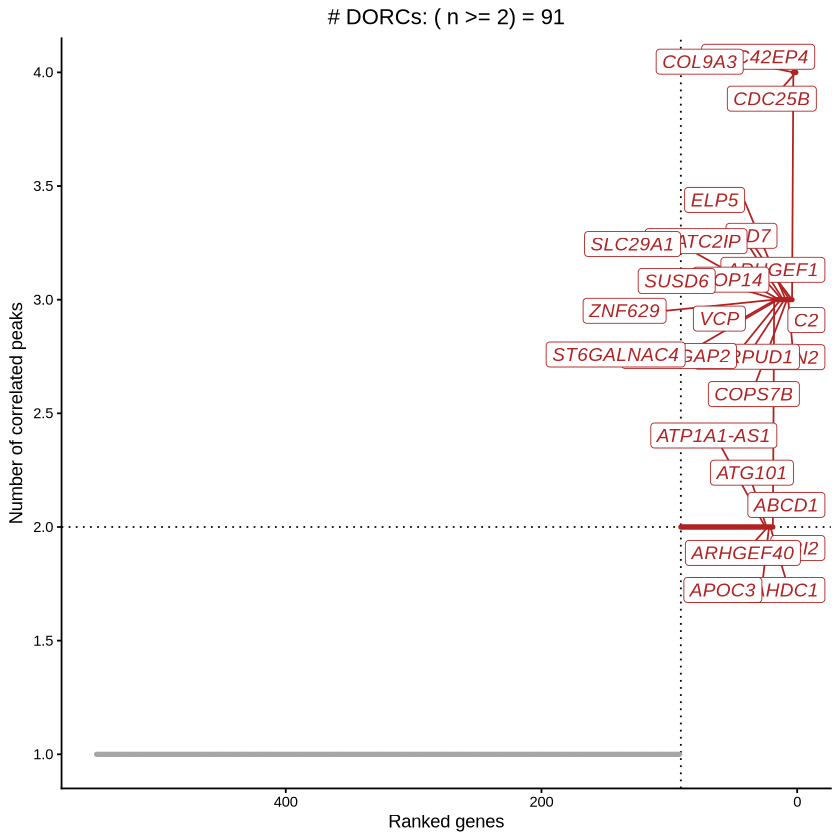

In [44]:
cisCor <- runGenePeakcorr(ATAC.se = ATAC.SE,
                          RNAmat = rnaMat,
                          genome = "hg38", # HepG2 通常使用 hg38 或 hg19
                          nCores = 4)

# 2. 筛选显著的关联
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)

# 3. 确定 DORC 基因列表 (默认相关峰数阈值为 7)
dorcGenes <- cisCor.filt %>% dorcJPlot(cutoff = 2, returnGeneList = TRUE)

# 4. 计算并平滑 DORC 得分
# 提示：cellKNN.mat 是细胞间的近邻矩阵，通常可通过 Seurat 的 FindNeighbors 结果构建
dorcMat <- getDORCScores(ATAC.SE, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 4)
dorcMat.smooth <- smoothScoresNN(NNmat = cellKNN.mat, mat = dorcMat, nCores = 4)

# GRN

In [52]:
# 运行 FigR
# rnaMat.smooth 建议使用经过平滑处理的 RNA 矩阵以提高信噪比
fig.d <- runFigRGRN(ATAC.se = ATAC.SE,
                    rnaMat = rnaMat.smooth, 
                    dorcMat = dorcMat.smooth,
                    dorcTab = cisCor.filt,
                    genome = "hg38",
                    dorcGenes = dorcGenes,
                    nCores = 4)

Assuming peak indices in Peak field



Using specified list of dorc genes ..


Removing genes with 0 expression across cells ..




Getting peak x motif matches ..



Attaching package: ‘BSgenome.Hsapiens.UCSC.hg38’


The following object is masked from ‘package:BSgenome.Hsapiens.UCSC.hg19’:

    Hsapiens




Determining background peaks ..
Using  50  iterations ..

Testing  93  TFs
Testing  91  DORCs


Running FigR using 4 cores ..




  |======================================================================| 100%Finished!
Merging results ..


Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”


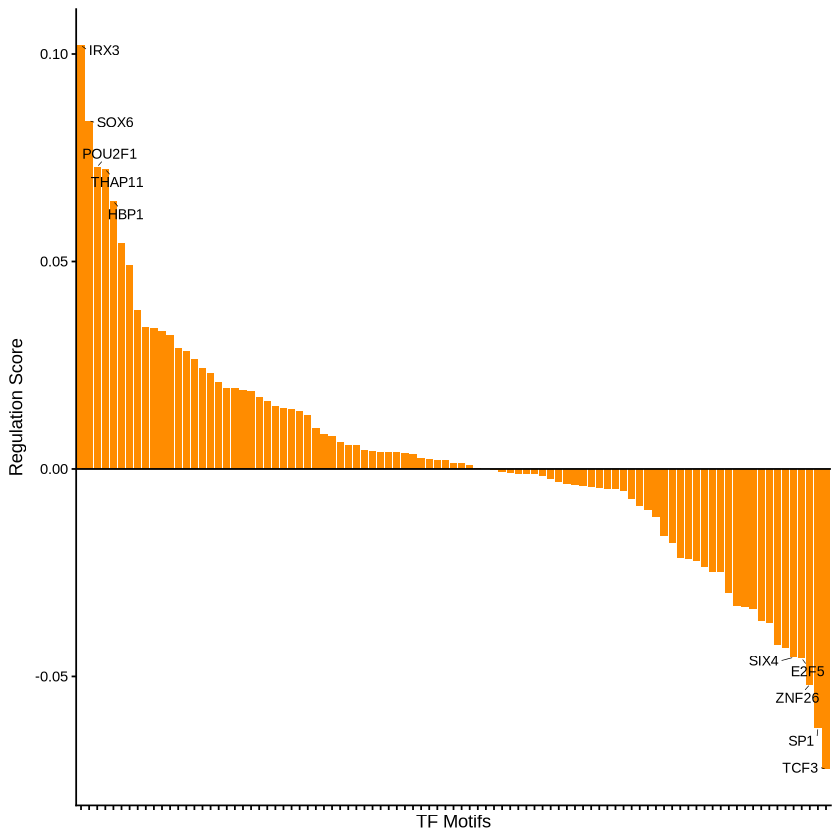

In [55]:
# 按平均调控得分对 TF 进行排名
rankDrivers(fig.d, rankBy = "meanScore", score.cut = 1)



 [1] "CDC25B"   "CDC42EP4" "COL9A3"   "ARHGEF1"  "C2"       "CD7"     
 [7] "CNN2"     "COPS7B"   "ELP5"     "HERPUD1" 
# A tibble: 6 × 2
  DORC     n_TFs
  <chr>    <int>
1 ABCD1       93
2 ABI2        93
3 AHDC1       93
4 APOC3       93
5 ARHGEF1     93
6 ARHGEF40    93


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


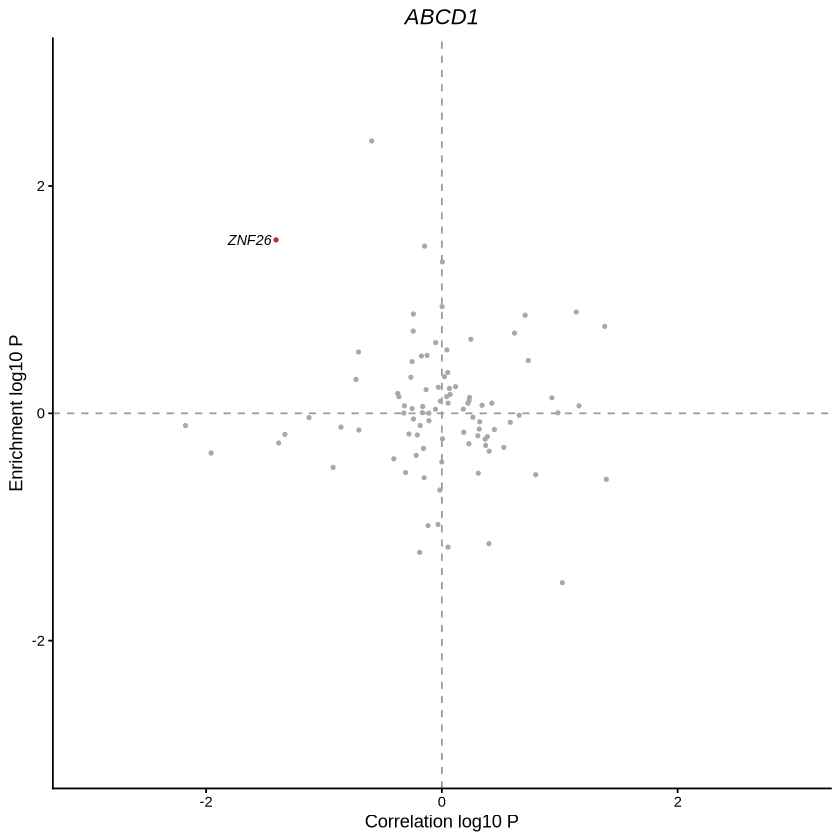

In [56]:
# 查看结果中包含的唯一 DORC 基因列表 (前 10 个)
print(head(unique(fig.d$DORC), 10))

# 或者，查看关联 TF 最多的前几个 DORC（往往更有生物学意义）
top_dorcs <- fig.d %>% 
  group_by(DORC) %>% 
  summarise(n_TFs = n()) %>% 
  arrange(desc(n_TFs))

print(head(top_dorcs))

# 假设查看 "GATA1" 基因
plotDrivers(fig.d, marker = "ABCD1", score.cut = 1)



In [58]:
plotfigRNetwork(fig.d, score.cut = 1.5)

HTML widgets cannot be represented in plain text (need html)

# Region-Gene

In [59]:
# 查看 Region-Gene 网络的前几行
head(cisCor.filt)

# 如果需要将 Peak 索引转换为更易读的格式（如果您之前的 Peak 是数字索引）
# FigR 输出通常已经包含了 "PeakRanges" 列，直接使用该列作为 Region ID
region_gene_df <- cisCor.filt[, c("PeakRanges", "Gene", "rObs", "pvalZ")]

# 重命名列以符合您的习惯
colnames(region_gene_df) <- c("Region", "Target_Gene", "Correlation", "P_Value")

# 导出为 CSV 文件
# write.csv(region_gene_df, "Region_Gene_Network.csv", row.names = FALSE)

,Peak,PeakRanges,Gene,rObs,pvalZ
,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,2165,chr1:3618732-3619265,TPRG1L,0.11154436,0.0111717438
2,2722,chr1:6179119-6180400,RNF207,0.08692791,0.0461165518
3,2724,chr1:6204962-6206606,RNF207,0.14423076,0.0001533224
4,2800,chr1:6634666-6635037,PHF13,0.08089530,0.0256450353
5,2815,chr1:6762047-6762534,CAMTA1,0.11758551,0.0007835080
6,2831,chr1:6807834-6808124,CAMTA1,0.11758551,0.0053142479


# TF-Gene

In [60]:
# 查看 TF-Gene 网络的前几行
head(fig.d)

# 通常我们只关心显著的调控关系（例如 absolute score > 1.0）
# 提取显著网络并转换为 Dataframe
tf_gene_df <- fig.d %>% 
  filter(abs(Score) >= 1.0) %>%
  select(Motif, DORC, Score, Corr, Enrichment.P)

# 重命名列
colnames(tf_gene_df) <- c("TF", "Target_Gene", "Regulation_Score", "Correlation", "Enrichment_PVal")

# 导出为 CSV 文件
# write.csv(tf_gene_df, "TF_Gene_Network.csv", row.names = FALSE)

,DORC,Motif,Enrichment.Z,Enrichment.P,Enrichment.log10P,Corr,Corr.Z,Corr.P,Corr.log10P,Score
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CDC25B,ARID3A,0.2947044,0.7682197,0.11451454,0.053219981,0.5367844,0.5914166,0.228106521,0.04320824
2,CDC25B,ARID5B,-0.4594556,0.6459070,-0.18983000,0.137535978,1.5701321,0.1163844,0.934105335,0.00000000
3,CDC25B,ATF6,0.7298004,0.4655122,0.33206896,-0.015515152,-0.3056097,0.7599019,-0.119242496,-0.05964767
4,CDC25B,ATF6B,-1.3365573,0.1813672,-0.74144130,0.063140662,0.6583688,0.5103012,0.292173445,0.00000000
5,CDC25B,ATF7,0.1218544,0.9030144,0.04430534,0.116201810,1.3086679,0.1906469,0.719770354,0.03550260
6,CDC25B,CREB1,-0.8027676,0.4221091,-0.37457531,0.008392691,-0.0126034,0.9899442,-0.004389282,0.00000000
